# ASSIGNMENT 8  : LOGISTIC REGRESSION

In [1]:

# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load the dataset

df = pd.read_csv("diabetes.csv")

# Display first 5 rows
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Dataset information (columns, data types, nulls)
df.info()

# Summary statistics
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Visualization

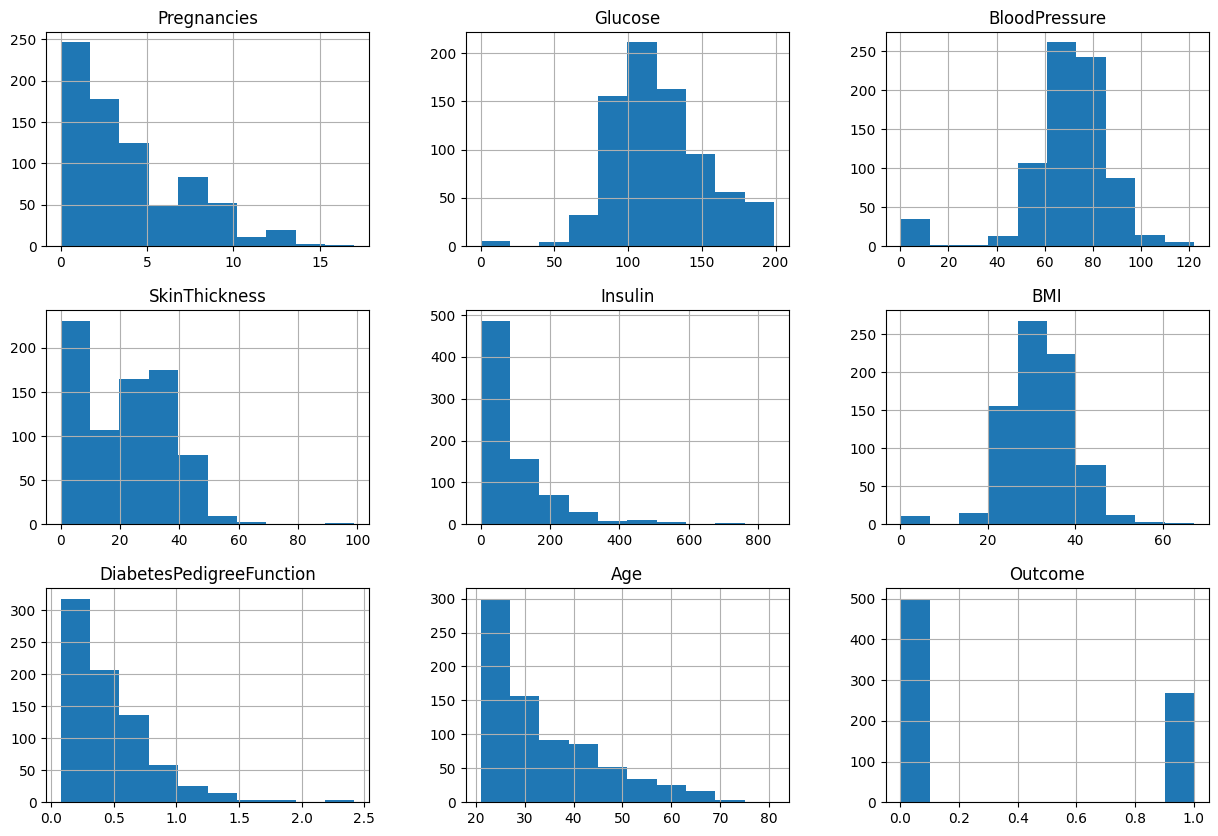

In [3]:
# ---------------------------------------------
# Histogram for each feature
# ---------------------------------------------
df.hist(figsize=(15, 10))
plt.show()


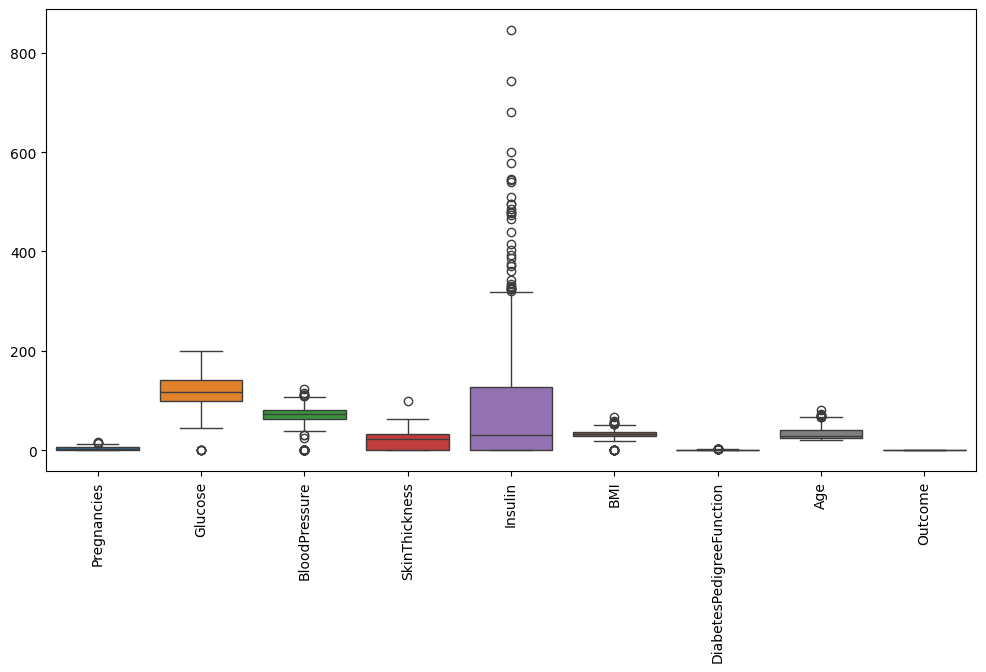

In [4]:
# Boxplot to detect outliers

plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()


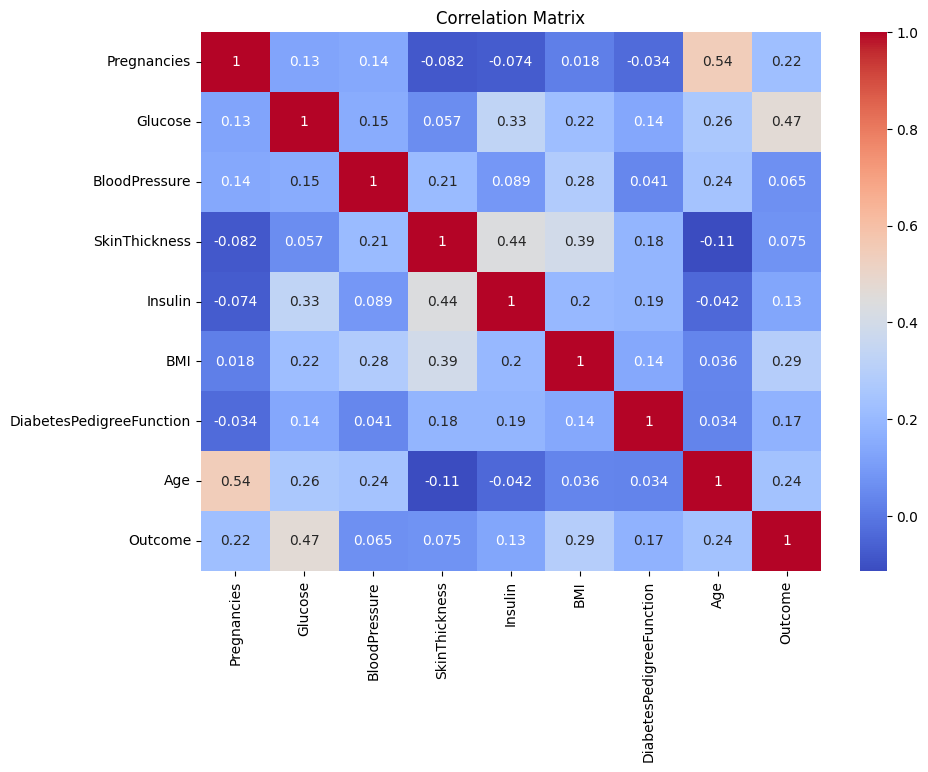

In [5]:

# Correlation Heatmap

plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


# DATA PREPROCESSING

In [6]:
# Columns where zero means missing
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace zero values with median
for col in cols_with_zero:
    df[col] = df[col].replace(0, df[col].median())


# MODEL BUILDING

In [7]:
# ---------------------------------------------
# Step 1: Separate features and target
# ---------------------------------------------
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# ---------------------------------------------
# Step 2: Train-test split
# ---------------------------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [8]:
# ---------------------------------------------
# Step 3: Feature Scaling
# ---------------------------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [9]:
# ---------------------------------------------
# Step 4: Build Logistic Regression Model
# ---------------------------------------------
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

# MODEL EVALUATION

In [10]:
# ---------------------------------------------
# Predictions
# ---------------------------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [11]:
# ---------------------------------------------
# Evaluation metrics
# ---------------------------------------------
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


Accuracy: 0.734375

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.80      0.80       123
           1       0.64      0.61      0.62        69

    accuracy                           0.73       192
   macro avg       0.71      0.71      0.71       192
weighted avg       0.73      0.73      0.73       192

ROC-AUC Score: 0.7953340402969247


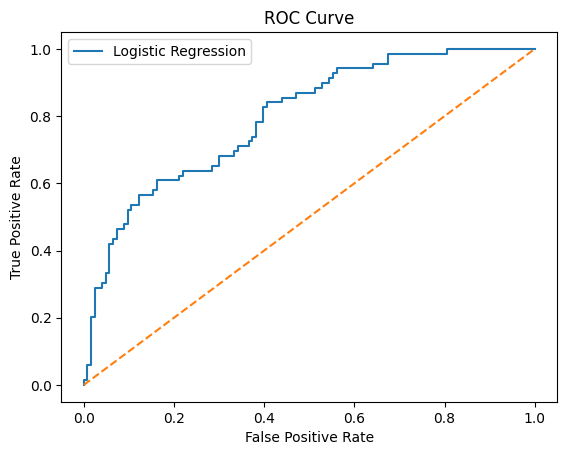

In [12]:

# ROC Curve Visualization

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [13]:
# INTERPRETATION
# Model Coefficients
#  Feature importance

coefficients = pd.DataFrame({
    "Feature": df.drop("Outcome", axis=1).columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(by="Coefficient", ascending=False)


,Feature,Coefficient
1,Glucose,1.205309
5,BMI,0.705953
7,Age,0.387123
0,Pregnancies,0.204415
6,DiabetesPedigreeFunction,0.155318
3,SkinThickness,0.078092
2,BloodPressure,-0.154302
4,Insulin,-0.195848


In [14]:
# save_model.py  (run once after training)
import pickle

# model = trained sklearn LogisticRegression
# scaler = fitted StandardScaler

with open("logistic_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


# INTERVIEW QUESTIONS

In [ ]:
#  Q 1. What is the difference between Precision and Recall?

# Precision and Recall are evaluation metrics used in classification problems.

# Precision measures how many of the predicted positive cases are actually positive. It focuses on reducing false positives.

# Precision = TP / (TP + FP)

# Recall measures how many of the actual positive cases are correctly predicted by the model. It focuses on reducing false negatives.

# Recall = TP / (TP + FN)

# Difference:

            # Precision answers: “Out of all predicted positives, how many were correct?”

            # Recall answers: “Out of all actual positives, how many were predicted correctly?”

            # In medical diagnosis problems, recall is often more important to ensure that patients with disease are not missed.





# Q 2. What is cross-validation, and why is it important in binary classification?

# Cross-validation is a technique used to evaluate a machine learning model by splitting the dataset into multiple parts. The model is trained on some parts and tested on the remaining part. This process is repeated multiple times.

# The most commonly used method is k-fold cross-validation.

# Cross-validation is important in binary classification because:

            # It gives a more accurate estimate of model performance

            # It helps reduce overfitting

            # It ensures the model generalizes well to unseen data

            # It ensures both classes are properly evaluated during training and testing
